## HW 3 ( 50 points)

#### Submit your homework as a. ipynb file. Use the format 'HW3_LastName_FirstName.ipynb'. Run your code and then submit the jupyter notebook. If there are no comments/markdown describing what you have done, your work will not be graded. Follow the code of conduct. 

##### Load the ceramic composition dataset as provided in the .csv file. Split the data into train and test with test being 20% of your data with a random state of 69. 

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the dataset from CSV file
data = pd.read_csv('ceramic_composition.csv')

# Assuming 'Ceramic Name' is the target variable for classification
X = data.drop('Ceramic Name', axis=1)  # Features
y = data['Ceramic Name']  # Target

# Split into training and test sets with 20% test size and a random state of 69
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=69)

##### Q1. Preprocess your data for classification (12 points) .<br> a) Make your data such that it has unit variance (2 poiints). <br> b) Check if your data has any outliers by using the z-score method and only keep observations in the training test that have a z-score of less than 3 (5 points). <br> c) List the features that have a correlation of less than 0.15 absolute correlation value with the output (5 points). 

In [12]:
from sklearn.preprocessing import StandardScaler

# StandardScaler scales features to have mean 0 and variance 1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit and transform training data
X_test_scaled = scaler.transform(X_test)        # Transform test data with the same scaler
import numpy as np

# Calculate z-scores for each feature in the training set
z_scores = np.abs((X_train_scaled - X_train_scaled.mean(axis=0)) / X_train_scaled.std(axis=0))

# Mask to remove observations where any feature's z-score exceeds 3
mask = (z_scores < 3).all(axis=1)

# Apply the mask to get clean training data
X_train_clean = X_train_scaled[mask]
y_train_clean = y_train[mask]

# Note: We don't adjust the test set for outliers to avoid data leakage
# Compute correlation between each feature and the target in the cleaned training set
correlation_matrix = pd.DataFrame(X_train_clean, columns=X.columns).corrwith(y_train_clean)

# Identify features with absolute correlation less than 0.15
low_correlation_features = correlation_matrix[abs(correlation_matrix) < 0.15].index.tolist()
print("Features with low correlation:", low_correlation_features)

Features with low correlation: ['Al2O3', 'SiO2', 'CaO', 'TiO2', 'Fe2O3', 'MnO', 'CuO', 'ZnO', 'PbO2', 'Rb2O', 'SrO', 'Y2O3', 'P2O5']


##### Q2. Apply decision tree classifier on the resulting data with a max_depth of 6 and a random state of 0 (4 points). Print the accuracy of the model on the test set (1 point).  Also visualize the decision tree as a graph (3 points). 

Accuracy of Decision Tree on test set: 0.8333333333333334


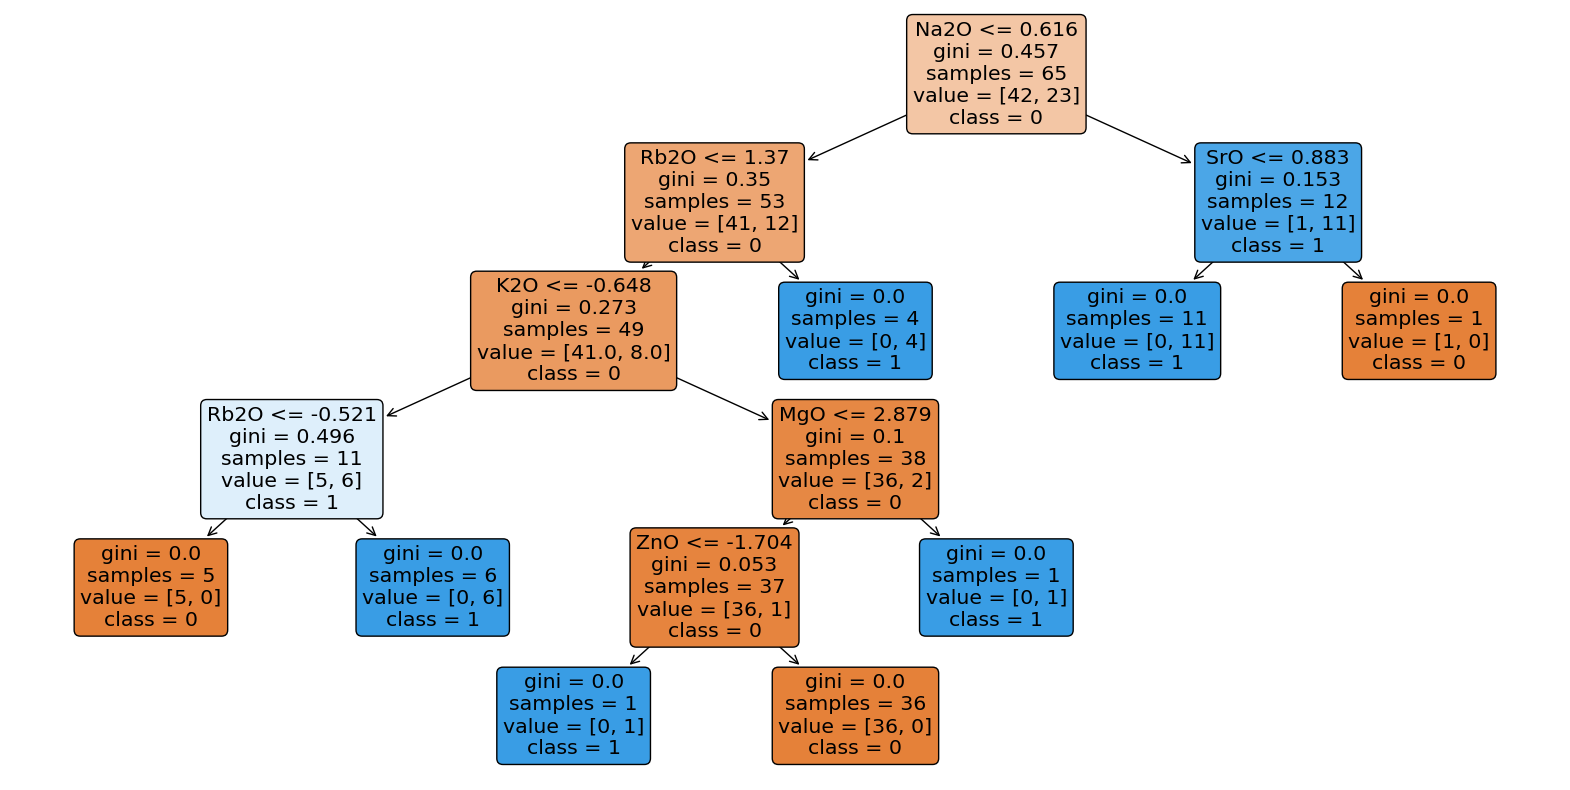

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt

# Train Decision Tree with max depth of 6 and random state of 0
dt_clf = DecisionTreeClassifier(max_depth=6, random_state=0)
dt_clf.fit(X_train_clean, y_train_clean)

# Predict on test set
y_pred = dt_clf.predict(X_test_scaled)

# Calculate accuracy
accuracy = dt_clf.score(X_test_scaled, y_test)
print(f"Accuracy of Decision Tree on test set: {accuracy}")

# Visualize the decision tree
plt.figure(figsize=(20,10))
tree.plot_tree(dt_clf, feature_names=X.columns, class_names=['0', '1'], filled=True, rounded=True)
plt.show()

##### Q3. Apply the SVM classifier with polynomial kernel. Change the degree of the polynominal from 1-10 and see how it affects the model accuracy by plotting the training and test accuracies. Discuss what would be an optimal choice. (10 points)

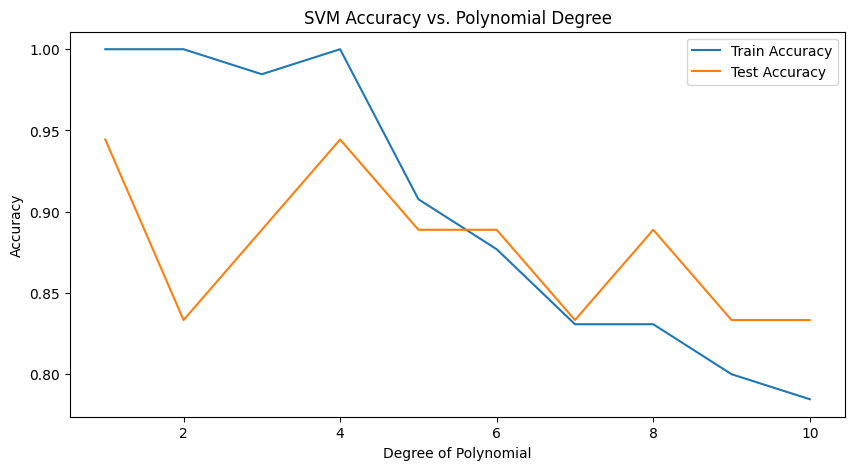

In [14]:
from sklearn.svm import SVC
import numpy as np

# Test different degrees of polynomial kernel
degrees = range(1, 11)
train_accuracies = []
test_accuracies = []

for degree in degrees:
    # SVM with polynomial kernel
    svm_clf = SVC(kernel='poly', degree=degree, random_state=0)
    svm_clf.fit(X_train_clean, y_train_clean)
    
    # Collect accuracies
    train_accuracies.append(svm_clf.score(X_train_clean, y_train_clean))
    test_accuracies.append(svm_clf.score(X_test_scaled, y_test))

# Plotting the accuracy vs. polynomial degrees
plt.figure(figsize=(10, 5))
plt.plot(degrees, train_accuracies, label='Train Accuracy')
plt.plot(degrees, test_accuracies, label='Test Accuracy')
plt.xlabel('Degree of Polynomial')
plt.ylabel('Accuracy')
plt.legend()
plt.title('SVM Accuracy vs. Polynomial Degree')
plt.show()

# Discussion on optimal choice:
# The optimal degree would be where the test accuracy is highest without significant overfitting.

##### Q4. Apply random forest classifier on the data with max_features of 2 and a random state of 0. number of trees by varying the depth from 1-5 at an interval of 1 and the number of tress from 5-50 at an interval of 5. Plot the training and test accuracies for both the cases and choose the optimal value of maximum depth and number of trees. Print the accuracy of the final model on the training and test data(20 points)

In [15]:
from sklearn.ensemble import RandomForestClassifier

# Vary depth and number of trees to find optimal parameters
depths = range(1, 6)
n_estimators = range(5, 51, 5)
train_acc = np.zeros((len(depths), len(n_estimators)))
test_acc = np.zeros((len(depths), len(n_estimators)))

for i, depth in enumerate(depths):
    for j, n_tree in enumerate(n_estimators):
        rf_clf = RandomForestClassifier(max_depth=depth, n_estimators=n_tree, max_features=2, random_state=0)
        rf_clf.fit(X_train_clean, y_train_clean)
        
        # Store accuracies
        train_acc[i, j] = rf_clf.score(X_train_clean, y_train_clean)
        test_acc[i, j] = rf_clf.score(X_test_scaled, y_test)

# Find the best combination of depth and trees based on test accuracy
optimal_depth = np.unravel_index(np.argmax(test_acc), test_acc.shape)[0] + 1
optimal_trees = np.unravel_index(np.argmax(test_acc), test_acc.shape)[1] * 5 + 5

print(f"Optimal depth: {optimal_depth}, Optimal number of trees: {optimal_trees}")

# Train the final model with optimal parameters
final_rf = RandomForestClassifier(max_depth=optimal_depth, n_estimators=optimal_trees, max_features=2, random_state=0)
final_rf.fit(X_train_clean, y_train_clean)

print(f"Final model train accuracy: {final_rf.score(X_train_clean, y_train_clean)}")
print(f"Final model test accuracy: {final_rf.score(X_test_scaled, y_test)}")

Optimal depth: 4, Optimal number of trees: 20
Final model train accuracy: 1.0
Final model test accuracy: 1.0
